# Flight Price Monitoring System - Exploration Notebook

This notebook demonstrates how to:
- Load raw flight price data
- Clean and process it
- Analyze price trends
- Visualize results


In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load dataset
df = pd.read_csv("../data/raw/flights.csv")
df["date"] = pd.to_datetime(df["date"])
df.head()


,date,route,price,airline
0,2024-01-01,HYD-DEL,4500,IndiGo
1,2024-01-01,HYD-MUM,3800,Air India
2,2024-01-01,HYD-BLR,3200,SpiceJet
3,2024-01-02,HYD-DEL,4600,IndiGo
4,2024-01-02,HYD-MUM,3700,Air India


## 1. Summary Statistics
Basic overview of the dataset.


In [2]:
print("Rows:", len(df))
print("Columns:", df.columns.tolist())
print("Average Price:", df["price"].mean())
print("Average Volume (if available):", df.get("volume", pd.Series()).mean())


Rows: 12
Columns: ['date', 'route', 'price', 'airline']
Average Price: 3845.8333333333335
Average Volume (if available): nan


## 2. Price Trend Analysis
Visualize how flight prices change over time.


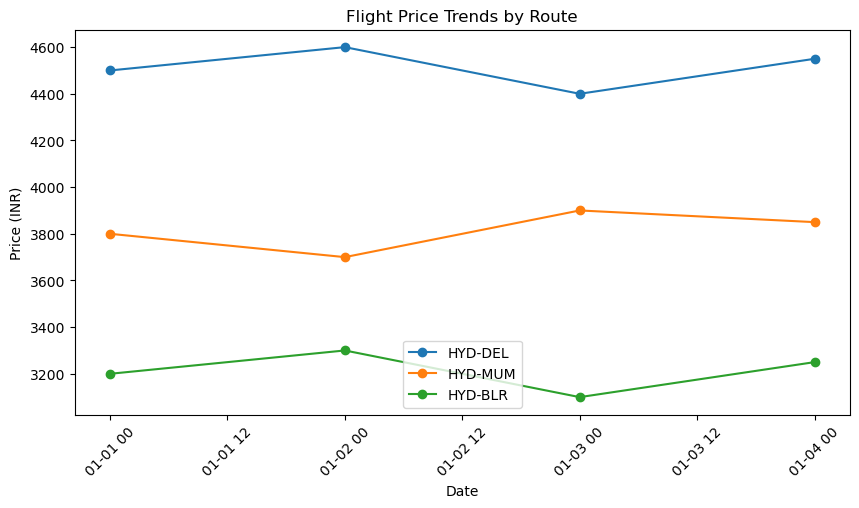

In [3]:
plt.figure(figsize=(10,5))
for route in df["route"].unique():
    subset = df[df["route"] == route]
    plt.plot(subset["date"], subset["price"], marker="o", label=route)

plt.title("Flight Price Trends by Route")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.xticks(rotation=45)
plt.show()


## 3. Moving Average
Smooth out price fluctuations with a rolling average.


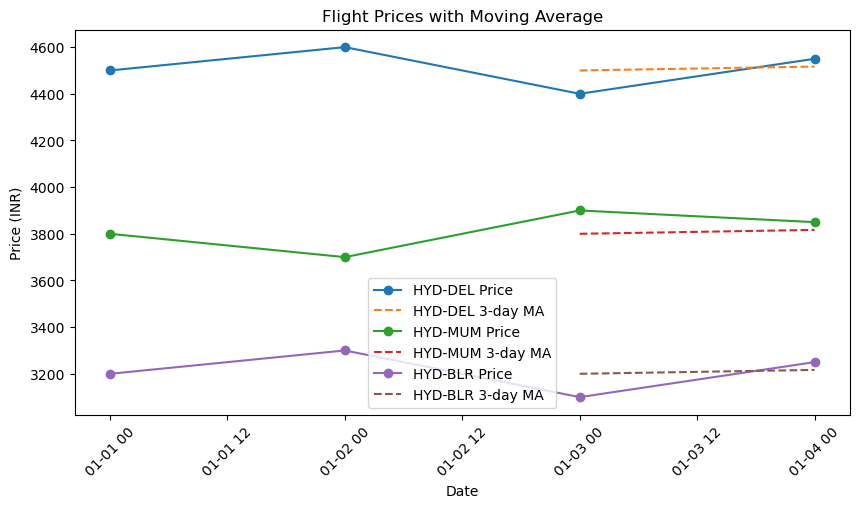

In [4]:
df["price_ma"] = df.groupby("route")["price"].transform(lambda x: x.rolling(window=3).mean())

plt.figure(figsize=(10,5))
for route in df["route"].unique():
    subset = df[df["route"] == route]
    plt.plot(subset["date"], subset["price"], marker="o", label=f"{route} Price")
    plt.plot(subset["date"], subset["price_ma"], linestyle="--", label=f"{route} 3-day MA")

plt.title("Flight Prices with Moving Average")
plt.xlabel("Date")
plt.ylabel("Price (INR)")
plt.legend()
plt.xticks(rotation=45)
plt.show()


## 4. Volatility Analysis
Measure daily percentage changes in price.


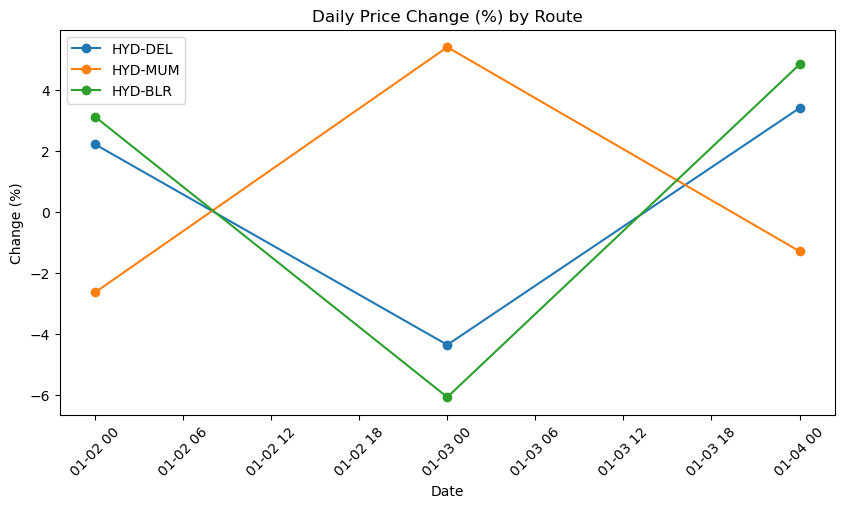

In [5]:
df["price_change_pct"] = df.groupby("route")["price"].pct_change() * 100

plt.figure(figsize=(10,5))
for route in df["route"].unique():
    subset = df[df["route"] == route]
    plt.plot(subset["date"], subset["price_change_pct"], marker="o", label=route)

plt.title("Daily Price Change (%) by Route")
plt.xlabel("Date")
plt.ylabel("Change (%)")
plt.legend()
plt.xticks(rotation=45)
plt.show()



## 5. Correlation Heatmap
Visualize correlations between numeric features.


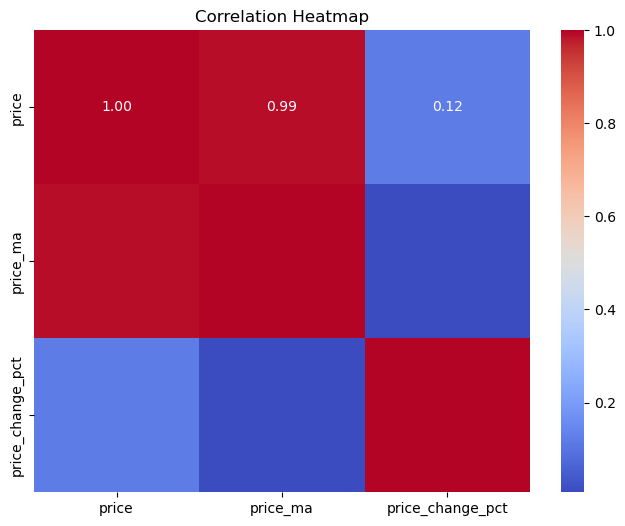

In [6]:
df_numeric = df.select_dtypes(include=["number"])
plt.figure(figsize=(8,6))
sns.heatmap(df_numeric.corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap")
plt.show()


## 6. Top 5 Routes by Average Price
Rank routes by their average price across all days.


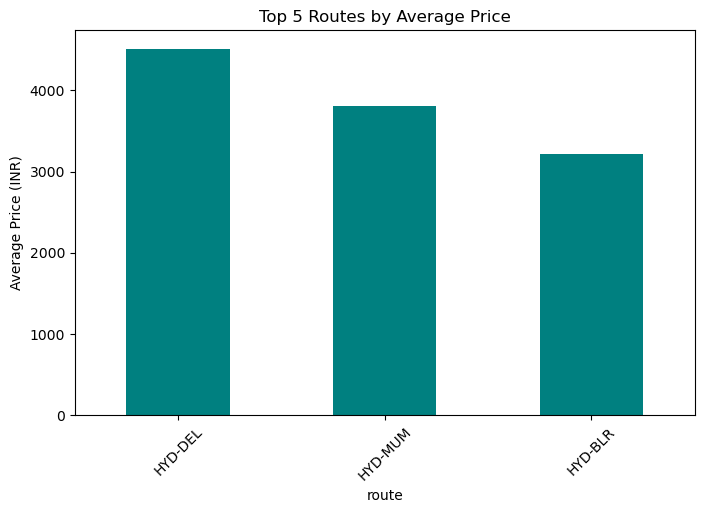

In [7]:
top5 = df.groupby("route")["price"].mean().sort_values(ascending=False).head(5)

plt.figure(figsize=(8,5))
top5.plot(kind="bar", color="teal")
plt.title("Top 5 Routes by Average Price")
plt.ylabel("Average Price (INR)")
plt.xticks(rotation=45)
plt.show()
